# Manipulating raster/vector data in Python

In this tutorial, we will learn some basic operations on raster/vector data in Python such as:
- read, write, reproject and display rasters and vectors
- running arithmetic operations on rasters
- rasterizing vectors, polygonizing rasters etc

We will make use of the **geoutils** library. This is not a "standard" Python library but was developed by glaciologists (R. Hugonnet, E. Mannerfelt, A. Dehecq, A. Tedstone), to make it easier to work with geospatial data (raster, vector) in Python. They are based upon the more known **rasterio/GDAL** and **geopandas** libraries.

The full documentation can be found at: \
https://geoutils.readthedocs.io. \

For more features, check the examples gallery on the documentation.

## Import the necessary modules

In [1]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib widget

import geoutils as gu

plt.rcParams["image.interpolation"] = "none"

## Sample data ###
The code comes with some data for showcasing the functionality. If not done already, the data will be downloaded when needed (takes a few seconds). \
Here we use two Landsat scenes over Mount Everest (one single-band, one RGB image), an ASTER DEM over Patagonia and glacier outlines from RGI. \
All available samples can be shown with:

In [2]:
print(gu.examples.available)

['everest_landsat_rgb', 'everest_landsat_b4', 'everest_landsat_b4_cropped', 'everest_rgi_outlines', 'exploradores_aster_dem', 'exploradores_rgi_outlines']


The files are already on disk, we only need to find their location, e.g.

In [3]:
print(gu.examples.get_path("everest_landsat_b4"))

/Users/adehecq/development/GlacioHack/geoutils/examples/data/Everest_Landsat/LE71400412000304SGS00_B4.tif


## Read the three rasters and glacier outlines ###

Raster files (e.g. GeoTiff) can be loaded in one line with `gu.Raster(path_to_file)`.

In [4]:
landsat_b4 = gu.Raster(gu.examples.get_path("everest_landsat_b4"))
landsat_rgb = gu.Raster(gu.examples.get_path("everest_landsat_rgb"))
aster_dem = gu.Raster(gu.examples.get_path("exploradores_aster_dem"))

Vector files (e.g. ESRI shapefiles) can be loaded in one line with `gu.Vector(path_to_file)`.

In [5]:
outlines = gu.Vector(gu.examples.get_path("everest_rgi_outlines"))

## Quickly visualize a raster
Since a Raster object comes with all atributes, it can be quickly plotted with its georeferencing information.

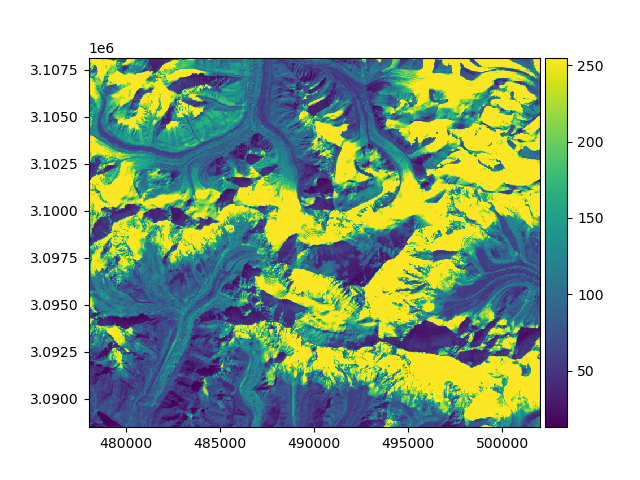

In [6]:
plt.figure()
landsat_b4.plot()
plt.show()

The default colorbar is viridis, one can set it grays to display in B&W

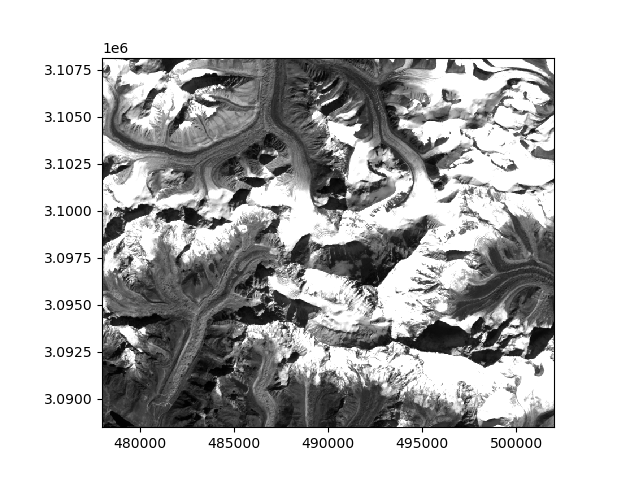

In [7]:
plt.figure()
landsat_b4.plot(cmap="gray", add_cbar=None)
plt.show()

For 3-band images, `Raster.plot` displays as RGB by default

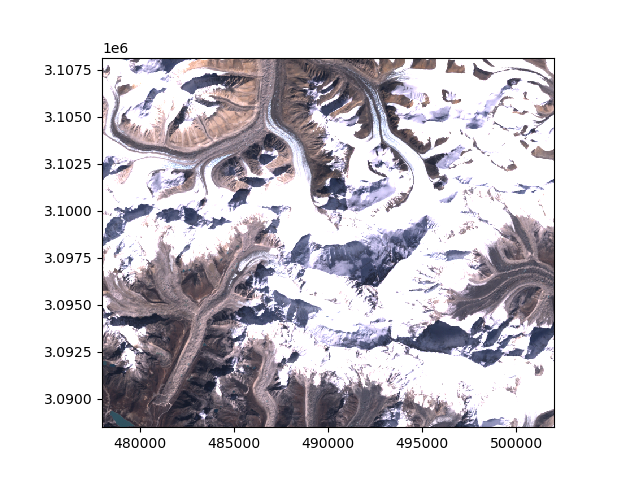

In [8]:
plt.figure()
landsat_rgb.plot()
plt.show()

## Quickly visualize vector data

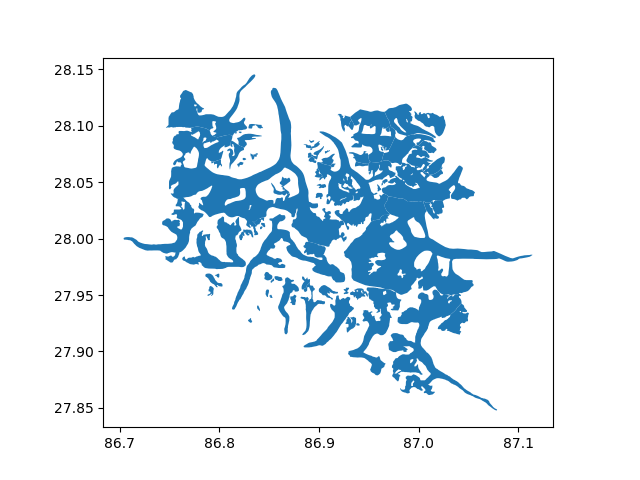

In [9]:
plt.figure()
outlines.plot()
plt.show()

## Superimpose layers or play with axes

One can pass a matplotlib Axes instance as argument to the plot function.

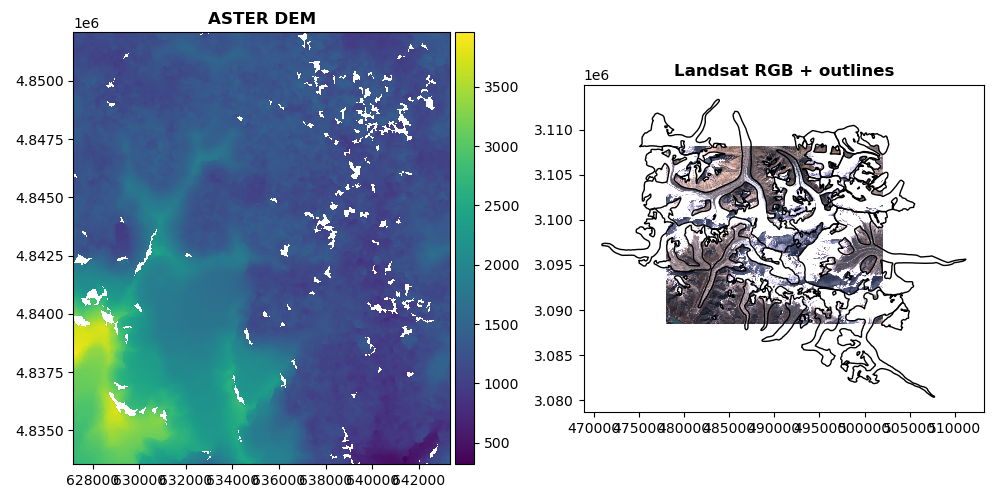

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

aster_dem.plot(ax=axes[0], title="ASTER DEM")

landsat_rgb.plot(ax=axes[1], title="Landsat RGB + outlines")
outlines.reproject(landsat_rgb).plot(ax=axes[1], ec="k", fc="none")

plt.tight_layout()
plt.show()

### Note on nodata

Nodata values are read from file and nodata values are masked using np.ma.masked_arrays.
The nodata value is stored in `self.nodata` and the mask in `self.data.mask`.

In [11]:
print(aster_dem.nodata)

-9999.0


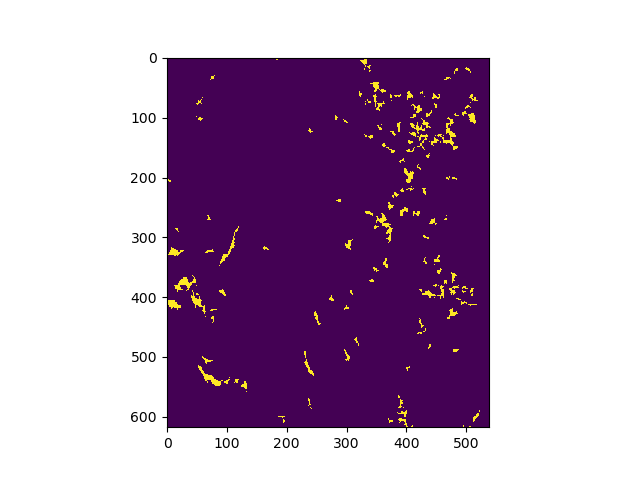

In [12]:
plt.figure()
plt.imshow(aster_dem.data.mask)
plt.show()

The best way to modify the mask is through `self.set_mask`.
All pixels where mask is set to True or > 0 will be masked (in addition to previously masked pixels).

<div class="alert alert-info" style="font-size:110%">
 <h3>Exercise</h3>

- print all information of landat_rdb dataset at once
- reproject the outlies onto the landsat_rgb CRS
- mask pixels with elevation > 2000 and make a plot of before/after masking
- crop the landsat_b4 raster to the extent (483530.0, 3093260.0, 498190.0, 3102730.0)
- get a Vector instance containing polygons of all pixels with landsat B4 values > 200 (~snow) and plot it on top of the original raster
- calculate and plot for each pixel the distance in meters to the nearest snow
- extract points every 200 m of gthe landsat_rgb dataset and export it to a pointcloud and plot
- calculate the mean value of all pixels within glaciers and + 500 m buffer

You can find the solutions in the **beginner/intro_geoutils.ipynb** file.
</div>